# Wind & Solar Profile Analysis

Visual exploration of the stochastic availability profiles generated by `SolarAvailability` and `WindAvailability`.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from energy_sim.models import TimeGrid
from energy_sim.generators import SolarAvailability, WindAvailability
from energy_sim.config import QUARTERS_PER_DAY, QUARTERS_PER_HOUR

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

tg = TimeGrid()
rng = np.random.default_rng(42)

solar_model = SolarAvailability()
wind_model = WindAvailability()

solar = solar_model.generate_profile(tg, rng)
wind = wind_model.generate_profile(tg, rng)

# Time axis in days (fractional)
t_days = np.arange(tg.n) / QUARTERS_PER_DAY

print(f'Solar — mean CF: {solar.mean():.3f}, max: {solar.max():.3f}')
print(f'Wind  — mean CF: {wind.mean():.3f}, max: {wind.max():.3f}')

Solar — mean CF: 0.135, max: 0.998
Wind  — mean CF: 0.102, max: 1.000


## 1. Full-Year Time Series

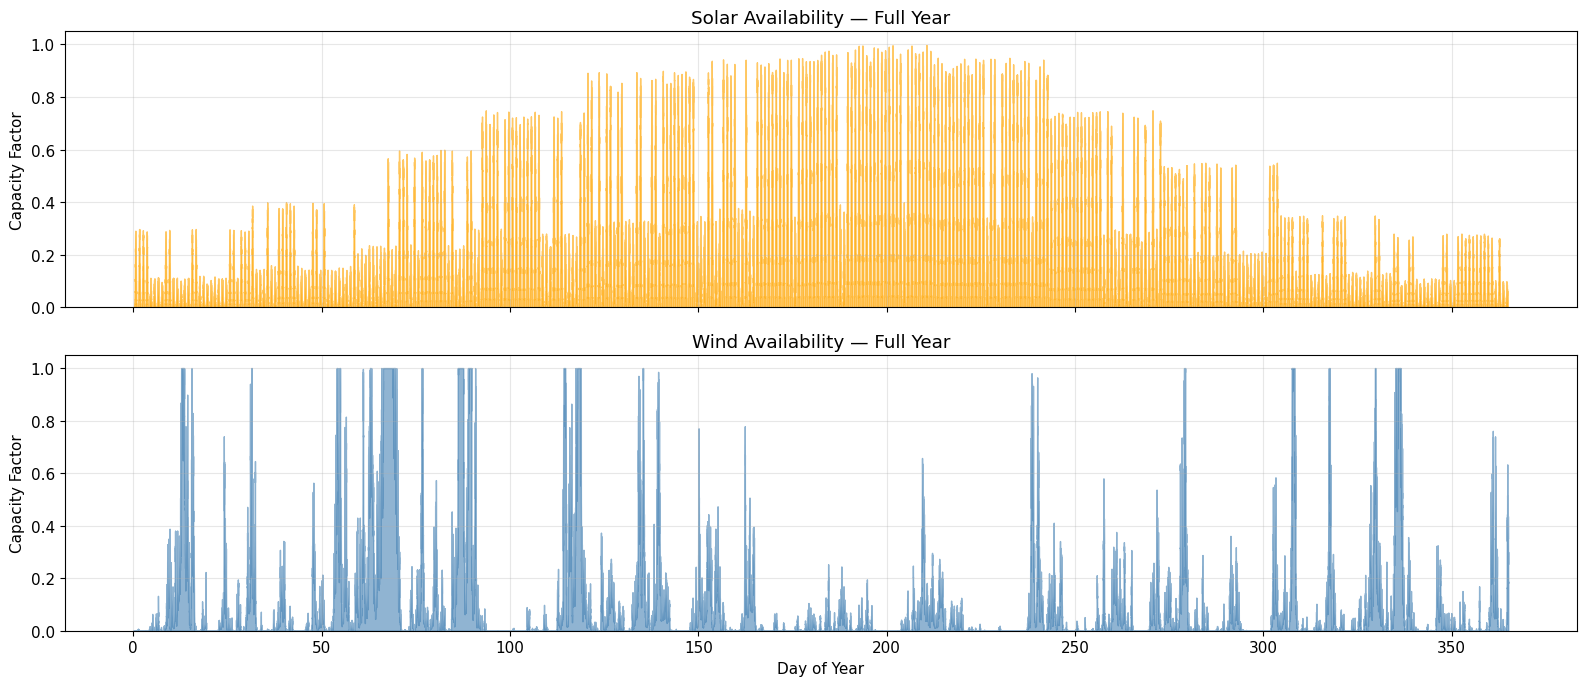

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].fill_between(t_days, solar, alpha=0.6, color='orange')
axes[0].set_ylabel('Capacity Factor')
axes[0].set_title('Solar Availability — Full Year')
axes[0].set_ylim(0, 1.05)

axes[1].fill_between(t_days, wind, alpha=0.6, color='steelblue')
axes[1].set_ylabel('Capacity Factor')
axes[1].set_title('Wind Availability — Full Year')
axes[1].set_ylim(0, 1.05)
axes[1].set_xlabel('Day of Year')

plt.tight_layout()
plt.show()

## 2. Zoom: One Summer Week vs One Winter Week

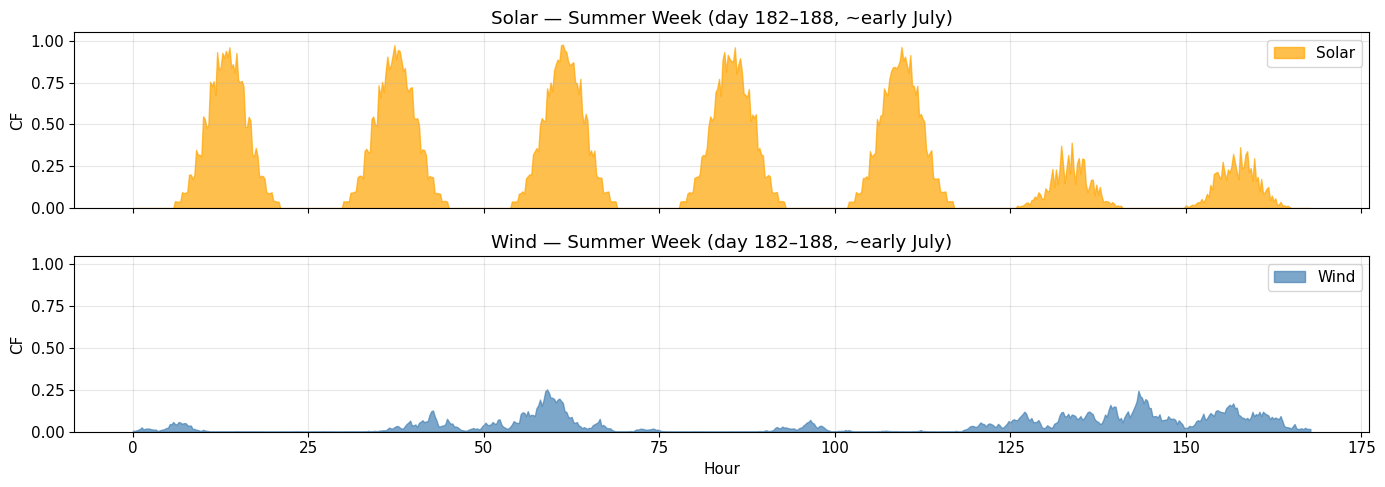

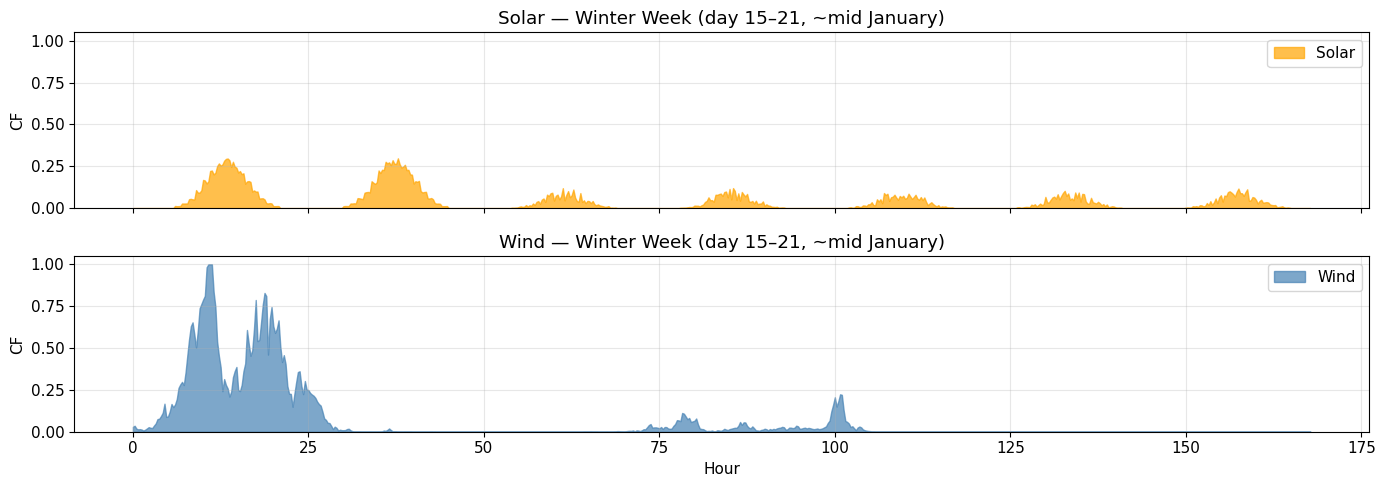

In [7]:
def plot_week(day_start, title_suffix):
    """Plot solar and wind for a 7-day window."""
    s = day_start * QUARTERS_PER_DAY
    e = s + 7 * QUARTERS_PER_DAY
    hours = np.arange(e - s) / QUARTERS_PER_HOUR  # hours within the window

    fig, axes = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
    axes[0].fill_between(hours, solar[s:e], alpha=0.7, color='orange', label='Solar')
    axes[0].set_ylabel('CF')
    axes[0].set_title(f'Solar — {title_suffix}')
    axes[0].set_ylim(0, 1.05)
    axes[0].legend(loc='upper right')

    axes[1].fill_between(hours, wind[s:e], alpha=0.7, color='steelblue', label='Wind')
    axes[1].set_ylabel('CF')
    axes[1].set_title(f'Wind — {title_suffix}')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xlabel('Hour')
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

plot_week(182, 'Summer Week (day 182–188, ~early July)')
plot_week(15,  'Winter Week (day 15–21, ~mid January)')

## 3. Capacity Factor Distributions (Histograms)

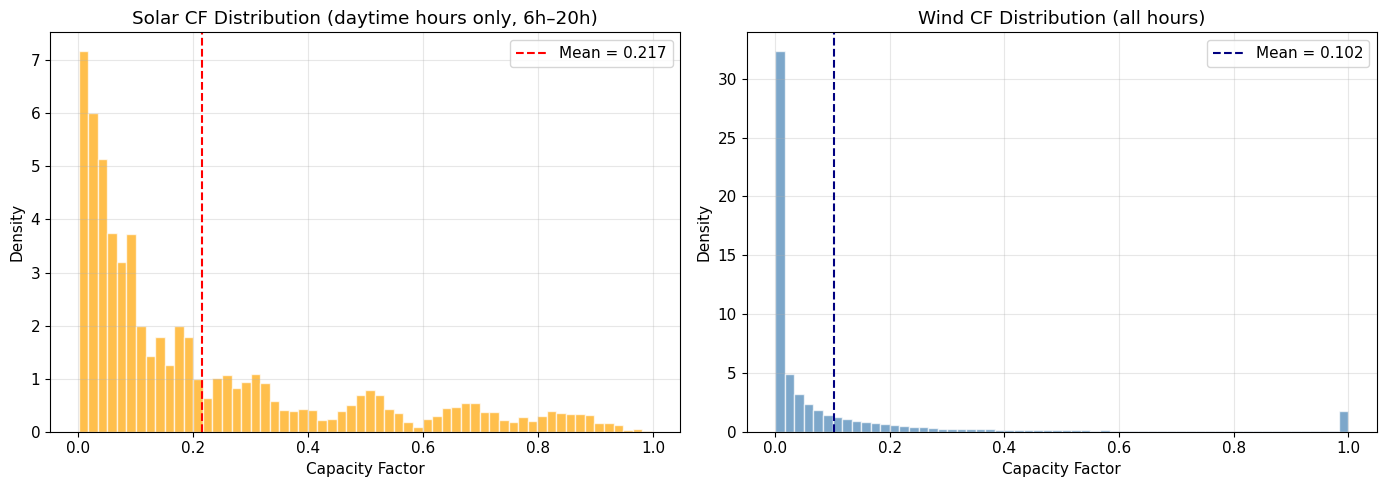

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Solar — only daytime hours (6-20) to avoid the trivial zero spike
day_mask = (tg.hour >= 6) & (tg.hour <= 20)
solar_day = solar[day_mask]

axes[0].hist(solar_day, bins=60, density=True, color='orange', alpha=0.7, edgecolor='white')
axes[0].axvline(solar_day.mean(), color='red', ls='--', label=f'Mean = {solar_day.mean():.3f}')
axes[0].set_title('Solar CF Distribution (daytime hours only, 6h–20h)')
axes[0].set_xlabel('Capacity Factor')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(wind, bins=60, density=True, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(wind.mean(), color='navy', ls='--', label=f'Mean = {wind.mean():.3f}')
axes[1].set_title('Wind CF Distribution (all hours)')
axes[1].set_xlabel('Capacity Factor')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Monthly Box Plots

/var/folders/tb/rzs9whln4mgg87g3dnb6q0qm0000gn/T/ipykernel_81636/2512443801.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = axes[0].boxplot(solar_by_month, labels=month_names, patch_artist=True,
/var/folders/tb/rzs9whln4mgg87g3dnb6q0qm0000gn/T/ipykernel_81636/2512443801.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = axes[1].boxplot(wind_by_month, labels=month_names, patch_artist=True,


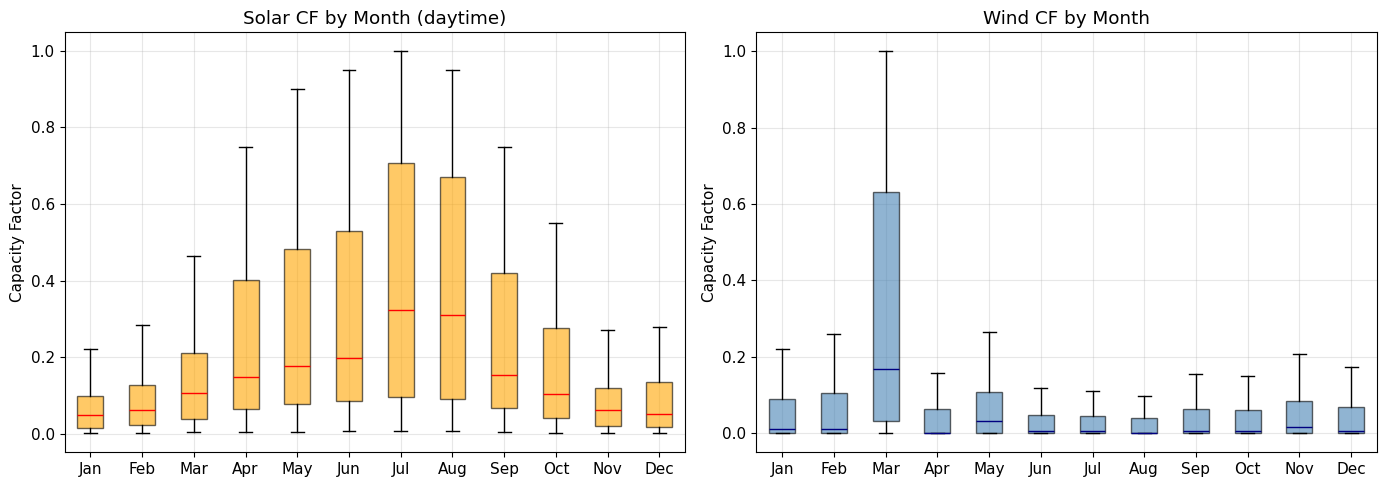

In [9]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

solar_by_month = [solar[(tg.month == m) & day_mask] for m in range(1, 13)]
wind_by_month = [wind[tg.month == m] for m in range(1, 13)]

bp1 = axes[0].boxplot(solar_by_month, labels=month_names, patch_artist=True,
                       showfliers=False, medianprops=dict(color='red'))
for patch in bp1['boxes']:
    patch.set_facecolor('orange')
    patch.set_alpha(0.6)
axes[0].set_title('Solar CF by Month (daytime)')
axes[0].set_ylabel('Capacity Factor')

bp2 = axes[1].boxplot(wind_by_month, labels=month_names, patch_artist=True,
                       showfliers=False, medianprops=dict(color='navy'))
for patch in bp2['boxes']:
    patch.set_facecolor('steelblue')
    patch.set_alpha(0.6)
axes[1].set_title('Wind CF by Month')
axes[1].set_ylabel('Capacity Factor')

plt.tight_layout()
plt.show()

## 5. Average Daily Profile by Season

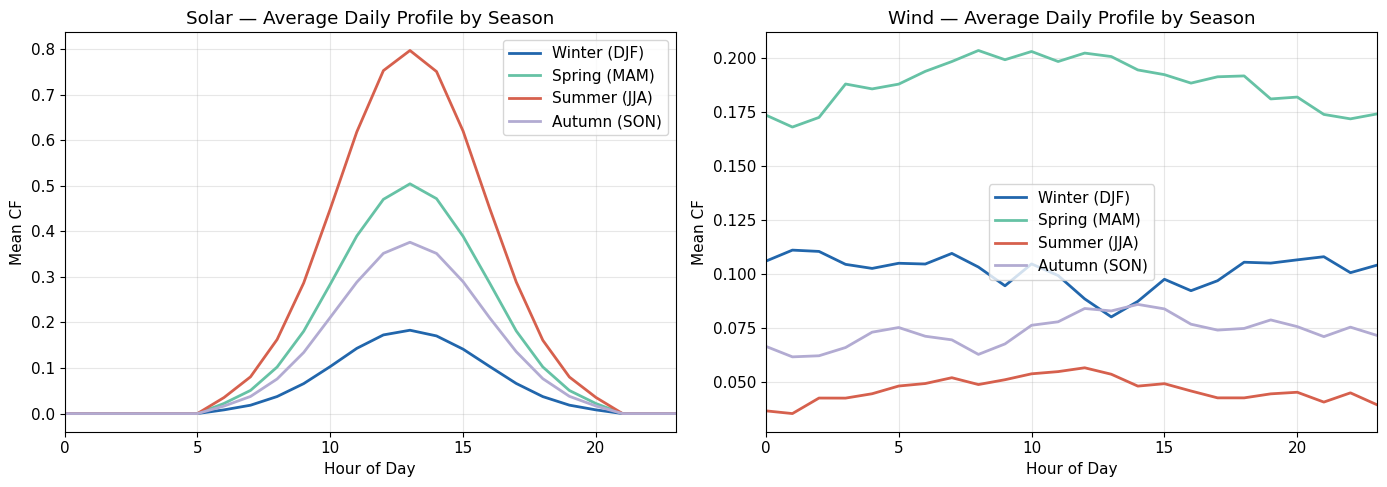

In [10]:
seasons = {
    'Winter (DJF)': [12, 1, 2],
    'Spring (MAM)': [3, 4, 5],
    'Summer (JJA)': [6, 7, 8],
    'Autumn (SON)': [9, 10, 11],
}
colors_s = ['#2166ac', '#66c2a5', '#d6604d', '#b2abd2']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hours = np.arange(24)

for (label, months), c in zip(seasons.items(), colors_s):
    mask = np.isin(tg.month, months)
    sol_avg = np.array([solar[mask & (tg.hour == h)].mean() for h in hours])
    wnd_avg = np.array([wind[mask & (tg.hour == h)].mean() for h in hours])
    axes[0].plot(hours, sol_avg, label=label, color=c, lw=2)
    axes[1].plot(hours, wnd_avg, label=label, color=c, lw=2)

axes[0].set_title('Solar — Average Daily Profile by Season')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Mean CF')
axes[0].set_xlim(0, 23)
axes[0].legend()

axes[1].set_title('Wind — Average Daily Profile by Season')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean CF')
axes[1].set_xlim(0, 23)
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Duration Curves

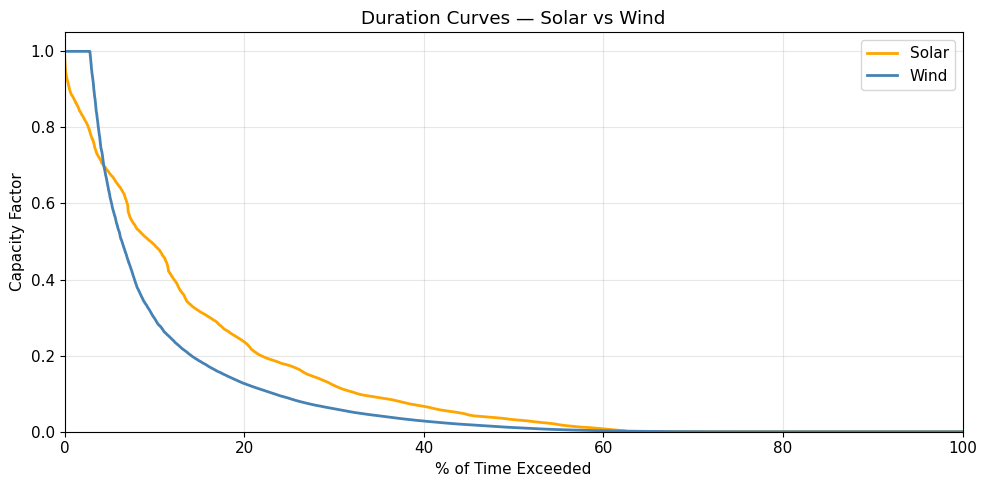

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

pct = np.linspace(0, 100, tg.n)

ax.plot(pct, np.sort(solar)[::-1], color='orange', lw=2, label='Solar')
ax.plot(pct, np.sort(wind)[::-1], color='steelblue', lw=2, label='Wind')
ax.set_xlabel('% of Time Exceeded')
ax.set_ylabel('Capacity Factor')
ax.set_title('Duration Curves — Solar vs Wind')
ax.legend()
ax.set_xlim(0, 100)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

## 7. Heatmap: Hour × Month Average CF

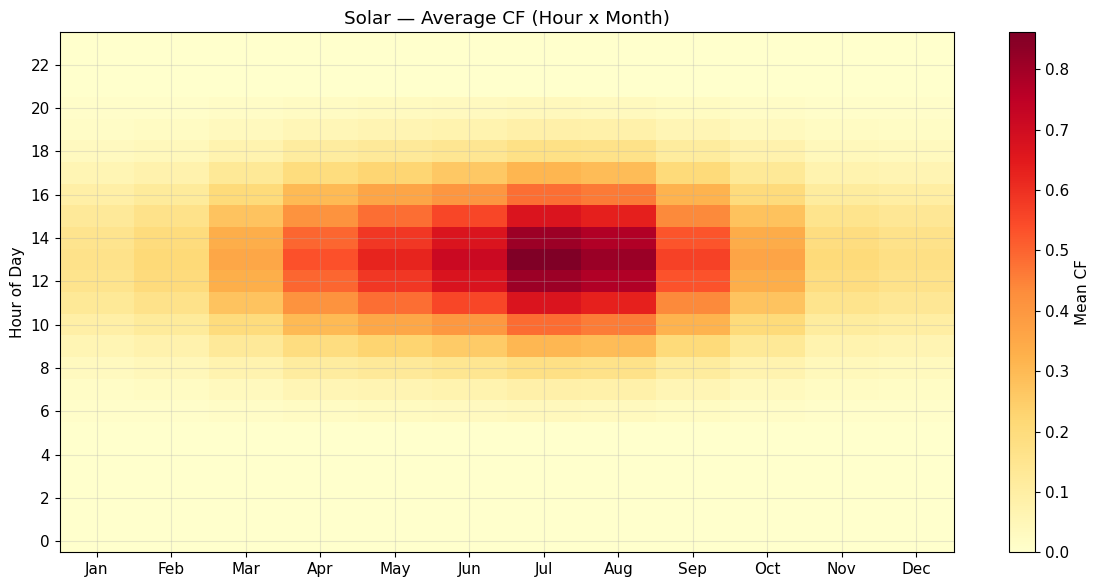

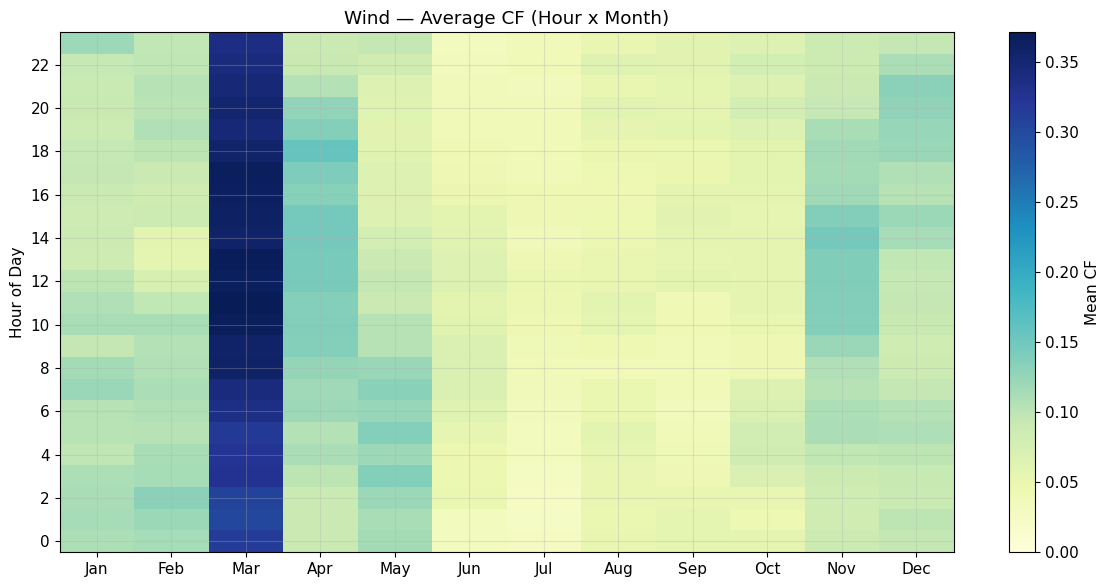

In [12]:
def hourly_monthly_heatmap(profile, title, cmap):
    """Plot a 24h x 12m heatmap of average capacity factor."""
    matrix = np.zeros((24, 12))
    for m in range(1, 13):
        for h in range(24):
            mask = (tg.month == m) & (tg.hour == h)
            matrix[h, m - 1] = profile[mask].mean()

    fig, ax = plt.subplots(figsize=(12, 6))
    im = ax.imshow(matrix, aspect='auto', origin='lower', cmap=cmap,
                   norm=Normalize(vmin=0, vmax=matrix.max()))
    ax.set_xticks(range(12))
    ax.set_xticklabels(month_names)
    ax.set_yticks(range(0, 24, 2))
    ax.set_ylabel('Hour of Day')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, label='Mean CF')
    plt.tight_layout()
    plt.show()

hourly_monthly_heatmap(solar, 'Solar — Average CF (Hour x Month)', 'YlOrRd')
hourly_monthly_heatmap(wind, 'Wind — Average CF (Hour x Month)', 'YlGnBu')

## 8. Autocorrelation Analysis

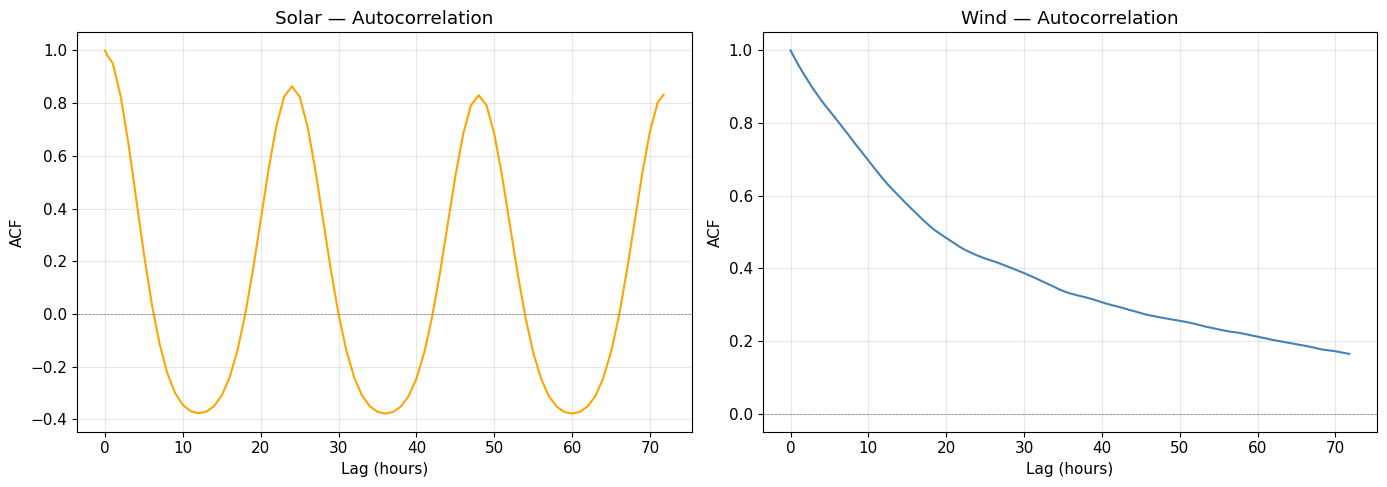

Wind lag-1h ACF:  0.9606
Wind lag-6h ACF:  0.8072
Wind lag-24h ACF: 0.4354


In [13]:
max_lag_hours = 72  # 3 days
max_lag = max_lag_hours * QUARTERS_PER_HOUR
lags_h = np.arange(max_lag) / QUARTERS_PER_HOUR

def autocorr(x, max_lag):
    """Compute autocorrelation for lags 0..max_lag-1."""
    x = x - x.mean()
    var = np.dot(x, x)
    return np.array([np.dot(x[:len(x)-k], x[k:]) / var for k in range(max_lag)])

acf_solar = autocorr(solar, max_lag)
acf_wind = autocorr(wind, max_lag)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(lags_h, acf_solar, color='orange', lw=1.5)
axes[0].set_title('Solar — Autocorrelation')
axes[0].set_xlabel('Lag (hours)')
axes[0].set_ylabel('ACF')
axes[0].axhline(0, color='gray', ls='--', lw=0.5)

axes[1].plot(lags_h, acf_wind, color='steelblue', lw=1.5)
axes[1].set_title('Wind — Autocorrelation')
axes[1].set_xlabel('Lag (hours)')
axes[1].set_ylabel('ACF')
axes[1].axhline(0, color='gray', ls='--', lw=0.5)

plt.tight_layout()
plt.show()

print(f'Wind lag-1h ACF:  {acf_wind[QUARTERS_PER_HOUR]:.4f}')
print(f'Wind lag-6h ACF:  {acf_wind[6*QUARTERS_PER_HOUR]:.4f}')
print(f'Wind lag-24h ACF: {acf_wind[24*QUARTERS_PER_HOUR]:.4f}')

## 9. Multi-Run Variability (Monte Carlo Ensemble)

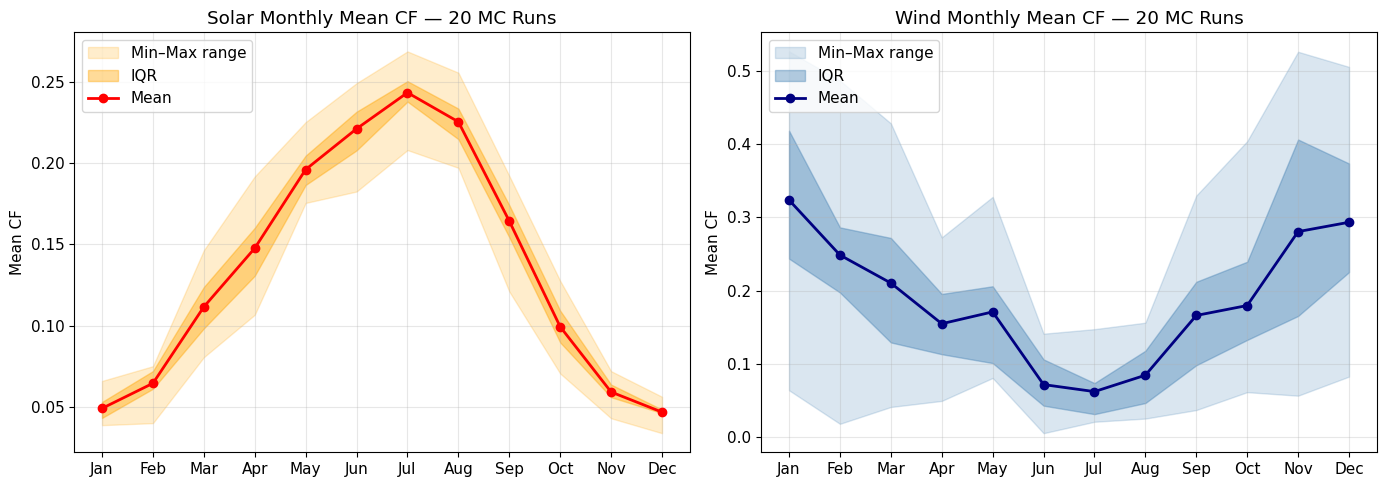

In [14]:
n_mc = 20
solar_runs = np.empty((n_mc, tg.n))
wind_runs = np.empty((n_mc, tg.n))

for i in range(n_mc):
    r = np.random.default_rng(i)
    solar_runs[i] = solar_model.generate_profile(tg, r)
    wind_runs[i] = wind_model.generate_profile(tg, r)

# Compute monthly mean CF per run
solar_monthly = np.zeros((n_mc, 12))
wind_monthly = np.zeros((n_mc, 12))
for m in range(1, 13):
    mask = tg.month == m
    solar_monthly[:, m-1] = solar_runs[:, mask].mean(axis=1)
    wind_monthly[:, m-1] = wind_runs[:, mask].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(12)
axes[0].fill_between(x, solar_monthly.min(axis=0), solar_monthly.max(axis=0),
                      alpha=0.2, color='orange', label='Min–Max range')
axes[0].fill_between(x,
                      np.percentile(solar_monthly, 25, axis=0),
                      np.percentile(solar_monthly, 75, axis=0),
                      alpha=0.4, color='orange', label='IQR')
axes[0].plot(x, solar_monthly.mean(axis=0), 'o-', color='red', lw=2, label='Mean')
axes[0].set_xticks(x)
axes[0].set_xticklabels(month_names)
axes[0].set_title(f'Solar Monthly Mean CF — {n_mc} MC Runs')
axes[0].set_ylabel('Mean CF')
axes[0].legend(loc='upper left')

axes[1].fill_between(x, wind_monthly.min(axis=0), wind_monthly.max(axis=0),
                      alpha=0.2, color='steelblue', label='Min–Max range')
axes[1].fill_between(x,
                      np.percentile(wind_monthly, 25, axis=0),
                      np.percentile(wind_monthly, 75, axis=0),
                      alpha=0.4, color='steelblue', label='IQR')
axes[1].plot(x, wind_monthly.mean(axis=0), 'o-', color='navy', lw=2, label='Mean')
axes[1].set_xticks(x)
axes[1].set_xticklabels(month_names)
axes[1].set_title(f'Wind Monthly Mean CF — {n_mc} MC Runs')
axes[1].set_ylabel('Mean CF')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

## 10. Annual CF Distribution Across MC Runs

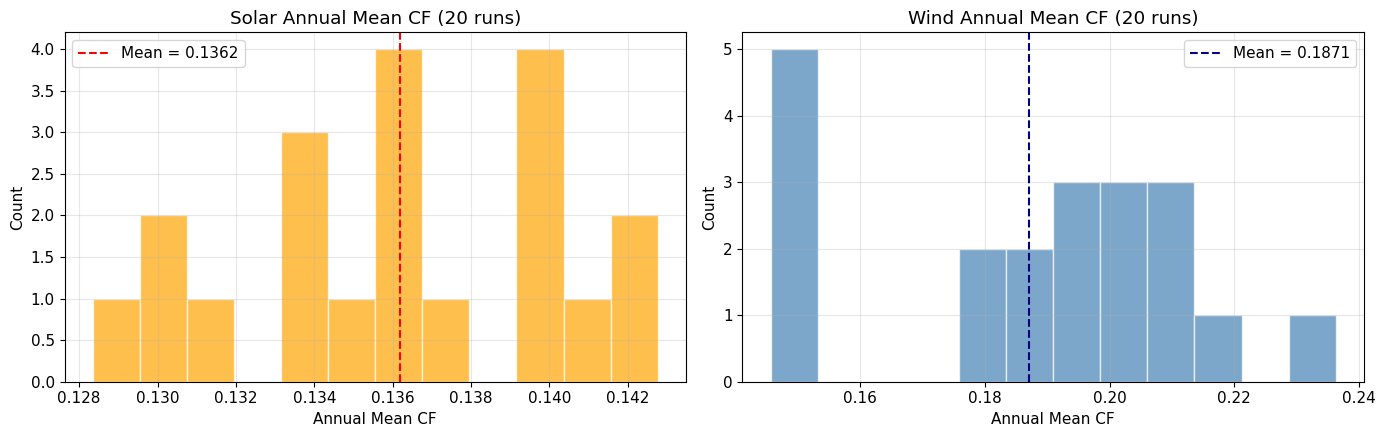

Solar annual CF: 0.1362 +/- 0.0040
Wind  annual CF: 0.1871 +/- 0.0255


In [15]:
solar_annual_cf = solar_runs.mean(axis=1)
wind_annual_cf = wind_runs.mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(solar_annual_cf, bins=12, color='orange', alpha=0.7, edgecolor='white')
axes[0].axvline(solar_annual_cf.mean(), color='red', ls='--',
                label=f'Mean = {solar_annual_cf.mean():.4f}')
axes[0].set_title(f'Solar Annual Mean CF ({n_mc} runs)')
axes[0].set_xlabel('Annual Mean CF')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(wind_annual_cf, bins=12, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(wind_annual_cf.mean(), color='navy', ls='--',
                label=f'Mean = {wind_annual_cf.mean():.4f}')
axes[1].set_title(f'Wind Annual Mean CF ({n_mc} runs)')
axes[1].set_xlabel('Annual Mean CF')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Solar annual CF: {solar_annual_cf.mean():.4f} +/- {solar_annual_cf.std():.4f}')
print(f'Wind  annual CF: {wind_annual_cf.mean():.4f} +/- {wind_annual_cf.std():.4f}')